In [26]:
# libararies
import pandas as pd
import numpy as np
import io
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn import tree
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

In [2]:
# upload and read the dataset
from google.colab import files
print ("Upload file: ")
uploaded = files.upload()
data = pd.read_csv(list(uploaded.keys())[0])


Upload file: 


Saving StudentPerformanceFactors (1).csv to StudentPerformanceFactors (1).csv


**STEP 1: CLEAN DATASET**

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [5]:
data.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [6]:
data.isin([0]).sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,1513


**Null observations:**

Teacher_Quality: 78

Parental_Education_Level: 90

Distance_From_Home: 67

**Non-Null but 0 observations**

Tutoring_Sessions: 1513

Physical_Activity: 46

**Unusual Observations**

Exam score of 101 - Remove observation

In [4]:
# remove observation
data = data[data["Exam_Score"] != 101]

**STEP 2: COMPUTE SUMMARY STATISTICS**

In [5]:
# Summary statistics for numeric variables
stats_numeric = data.describe(include= [np.number])
stats_numeric.round(2)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6606.00,6606.00,6606.00,6606.00,6606.00,6606.00,6606.00
mean,19.97,79.97,7.03,75.07,1.49,2.97,67.23
std,5.99,11.55,1.47,14.40,1.23,1.03,3.87
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,100.00


In [ ]:
# Summary statistics for non-numeric variables
stats_object = data.describe(include = [object])
stats_object

,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
count,6606,6606,6606,6606,6606,6606,6528,6606,6606,6606,6516,6539,6606
unique,3,3,2,3,2,3,3,2,3,2,3,3,2
top,Medium,Medium,Yes,Medium,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
freq,3362,3318,3937,3351,6108,2672,3925,4597,2637,5911,3222,3884,3814


**Plots for Numerical feautures**

{'whiskers': [<matplotlib.lines.Line2D at 0x799b70cb5940>,
 'caps': [<matplotlib.lines.Line2D at 0x799b70cb5f40>,
 'boxes': [<matplotlib.patches.PathPatch at 0x799b71611580>],
 'medians': [<matplotlib.lines.Line2D at 0x799b710c0890>],
 'fliers': [<matplotlib.lines.Line2D at 0x799b710c0ef0>],
 'means': []}

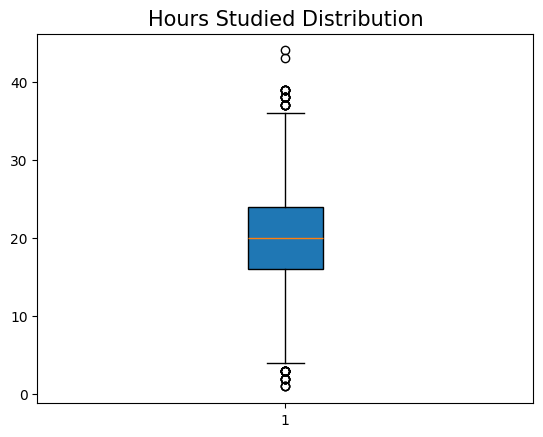

In [ ]:
# Hours studied plot
plt.title('Hours Studied Distribution', fontsize = 15)
plt.boxplot(data = data, x ='Hours_Studied', patch_artist = True)

{'whiskers': [<matplotlib.lines.Line2D at 0x799b71092d80>,
 'caps': [<matplotlib.lines.Line2D at 0x799b70cb7410>,
 'boxes': [<matplotlib.patches.PathPatch at 0x799b70cb5f10>],
 'medians': [<matplotlib.lines.Line2D at 0x799b70cb7a40>],
 'fliers': [<matplotlib.lines.Line2D at 0x799b70cb7d40>],
 'means': []}

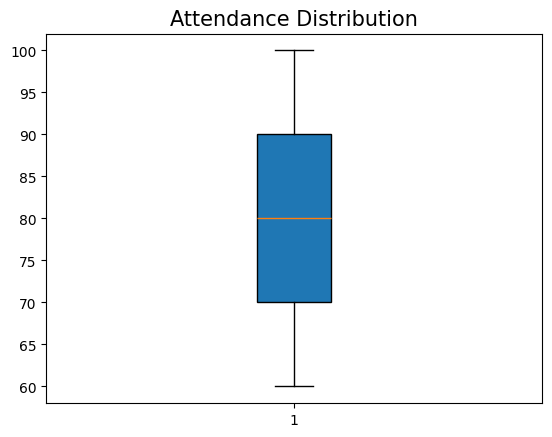

In [ ]:
# Attendance plot
plt.title('Attendance Distribution', fontsize = 15)
plt.boxplot(data = data, x ='Attendance', patch_artist = True)

{'whiskers': [<matplotlib.lines.Line2D at 0x799b6ca39880>,
 'caps': [<matplotlib.lines.Line2D at 0x799b6ca39e80>,
 'boxes': [<matplotlib.patches.PathPatch at 0x799b6ca394f0>],
 'medians': [<matplotlib.lines.Line2D at 0x799b6ca3a450>],
 'fliers': [<matplotlib.lines.Line2D at 0x799b6ca3a750>],
 'means': []}

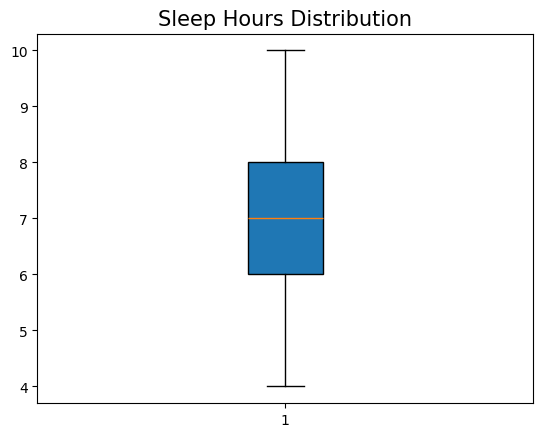

In [ ]:
# Sleep hours plot
plt.title('Sleep Hours Distribution', fontsize = 15)
plt.boxplot(data = data, x = 'Sleep_Hours', patch_artist = True)

{'whiskers': [<matplotlib.lines.Line2D at 0x799b6c8ed220>,
 'caps': [<matplotlib.lines.Line2D at 0x799b6c8ed820>,
 'boxes': [<matplotlib.patches.PathPatch at 0x799b6ca774a0>],
 'medians': [<matplotlib.lines.Line2D at 0x799b6c8edd30>],
 'fliers': [<matplotlib.lines.Line2D at 0x799b6c8ee060>],
 'means': []}

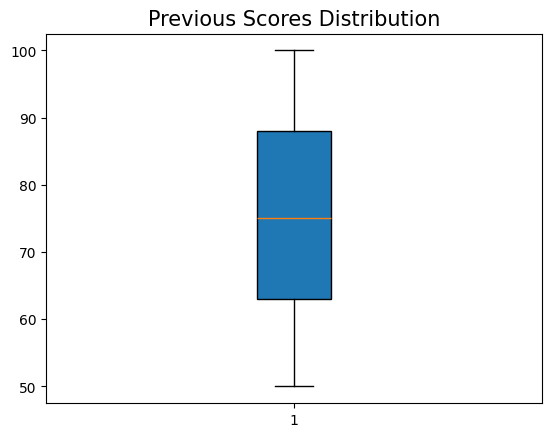

In [ ]:
# previous scores distribution
plt.title('Previous Scores Distribution', fontsize = 15)
plt.boxplot(data= data, x = 'Previous_Scores', patch_artist= True)

<Axes: title={'center': 'Tutoring Sessions Distribution'}, xlabel='Tutoring_Sessions', ylabel='Count'>

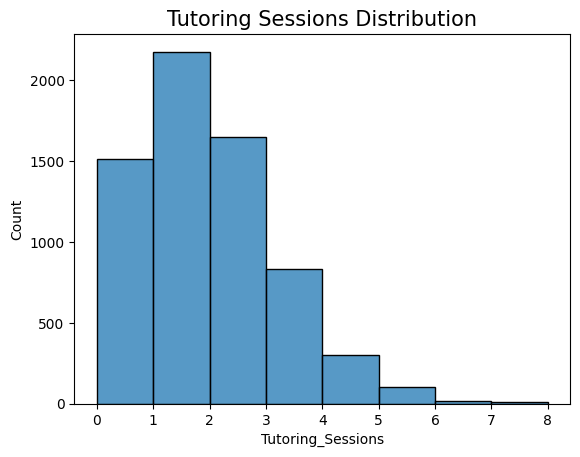

In [ ]:
# Tutoring plot
plt.title('Tutoring Sessions Distribution', fontsize = 15)
sns.histplot(data = data, x = 'Tutoring_Sessions', binwidth = 1)

<Axes: title={'center': 'Physical Activity Distribution'}, xlabel='Physical_Activity', ylabel='Count'>

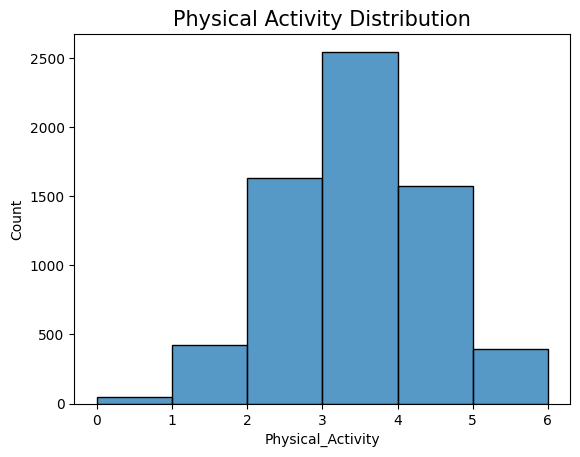

In [ ]:
# Physical activity plot
plt.title('Physical Activity Distribution', fontsize = 15)
sns.histplot(data = data, x = 'Physical_Activity', binwidth = 1)

<Axes: title={'center': 'Exam Score Distribution'}, xlabel='Exam_Score', ylabel='Count'>

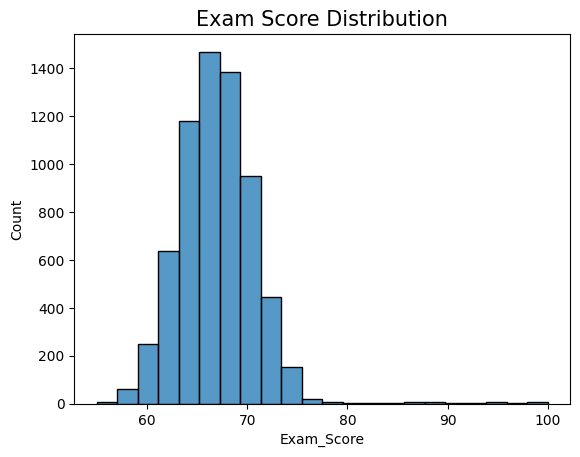

In [ ]:
# exam score distribution
plt.title('Exam Score Distribution', fontsize = 15)
sns.histplot(data= data, x = 'Exam_Score', binwidth = 2)

Text(0.5, 1.0, 'Hours Studied vs Exam Scores')

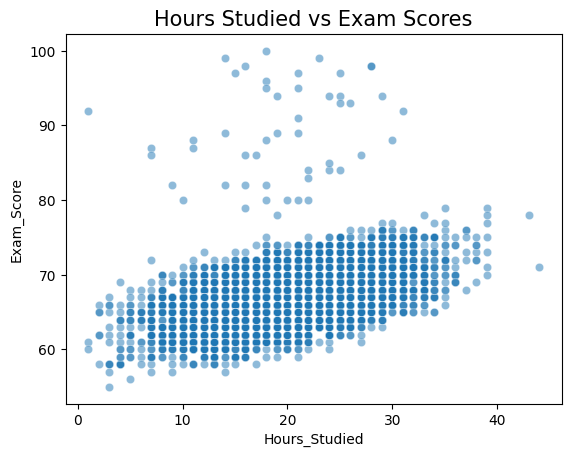

In [9]:
# scatter plot for correlation between hours studied and exam scores
sns.scatterplot(x = 'Hours_Studied', y ='Exam_Score', data = data, alpha = 0.5)
plt.title('Hours Studied vs Exam Scores', fontsize = 15)

**Plots for Non-Numerical features:**

Text(0.5, 1.0, 'Parental vs Exam Score')

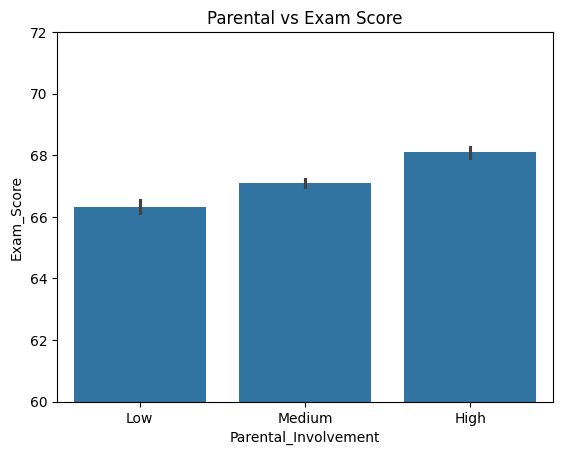

In [127]:
sns.barplot(x='Parental_Involvement', y='Exam_Score', data=data, order = ['Low', 'Medium', 'High'])
plt.ylim(60, 72)
plt.title('Parental vs Exam Score')

Text(0.5, 1.0, 'Access to Resources vs Exam Score')

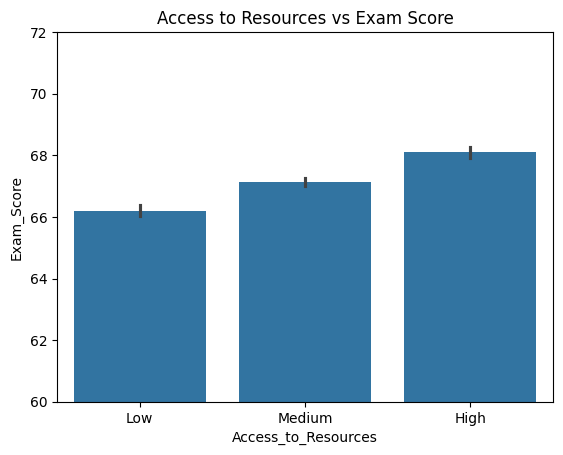

In [126]:
sns.barplot(x='Access_to_Resources', y='Exam_Score', data=data, order = ['Low', 'Medium', 'High'])
plt.ylim(60, 72)
plt.title('Access to Resources vs Exam Score')

Text(0.5, 1.0, 'Peer Influence vs Exam Score')

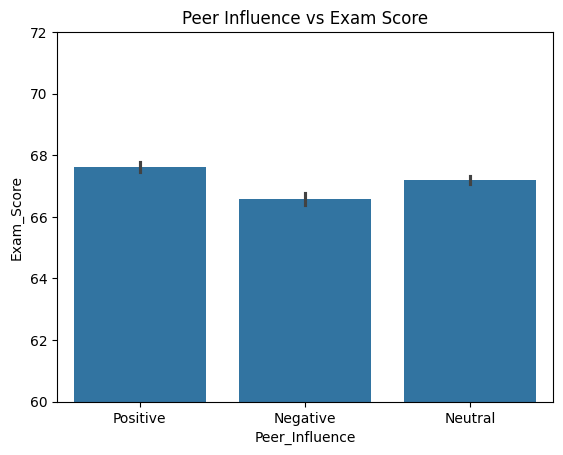

In [111]:
sns.barplot(x='Peer_Influence', y='Exam_Score', data=data)
plt.ylim(60, 72)
plt.title('Peer Influence vs Exam Score')

Text(0.5, 1.0, 'Disabilities vs Exam Score')

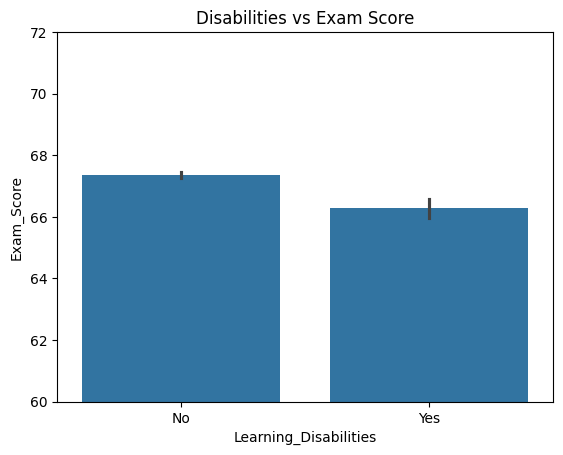

In [113]:
sns.barplot(x='Learning_Disabilities', y='Exam_Score', data=data)
plt.ylim(60, 72)
plt.title('Disabilities vs Exam Score')

Text(0.5, 1.0, 'Distance vs Exam Score')

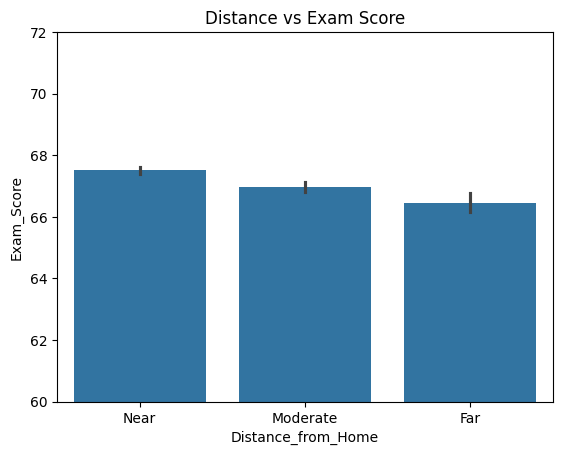

In [114]:
sns.barplot(x='Distance_from_Home', y='Exam_Score', data=data)
plt.ylim(60, 72)
plt.title('Distance vs Exam Score')

Text(0.5, 1.0, 'Income vs Exam Score')

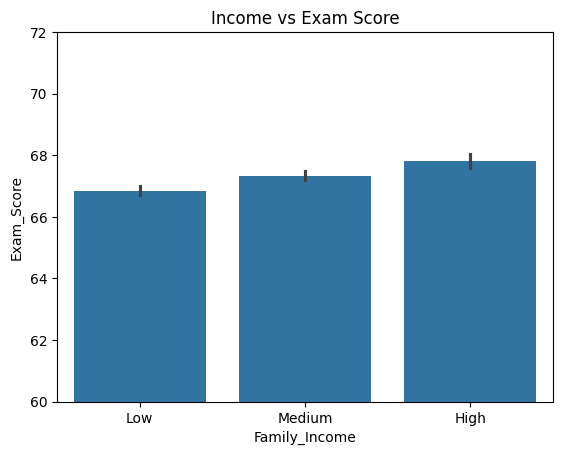

In [125]:
sns.barplot(x='Family_Income', y='Exam_Score', data=data, order = ['Low', 'Medium', 'High'])
plt.ylim(60, 72)
plt.title('Income vs Exam Score')

Text(0.5, 1.0, 'Parental Education vs Exam Score')

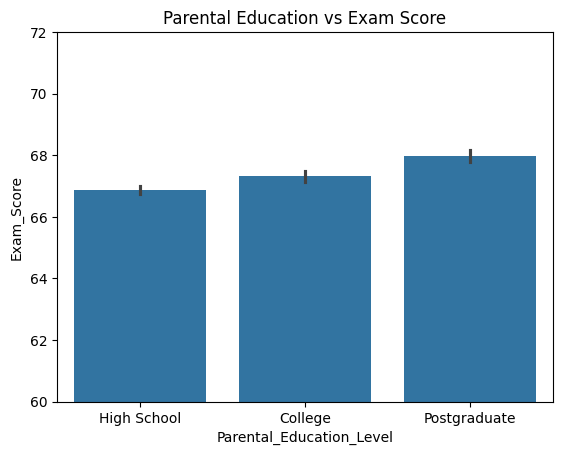

In [124]:
sns.barplot(x='Parental_Education_Level', y='Exam_Score', data=data)
plt.ylim(60, 72)
plt.title('Parental Education vs Exam Score')

Text(0.5, 1.0, 'Teacher quality vs Exam Score')

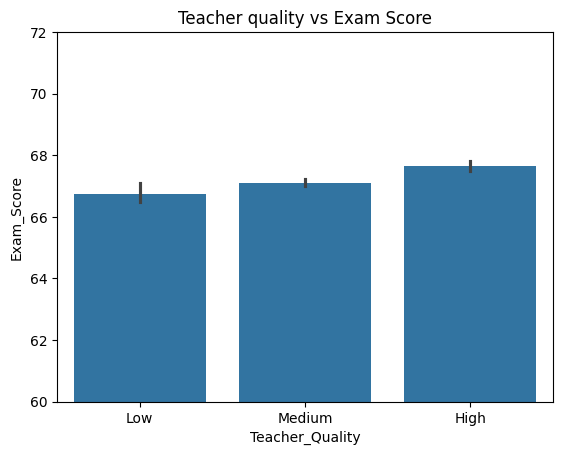

In [97]:
sns.barplot(x='Teacher_Quality', y='Exam_Score', data=data, order = ['Low', 'Medium', 'High'])
plt.ylim(60, 72)
plt.title('Teacher quality vs Exam Score')

(60.0, 72.0)

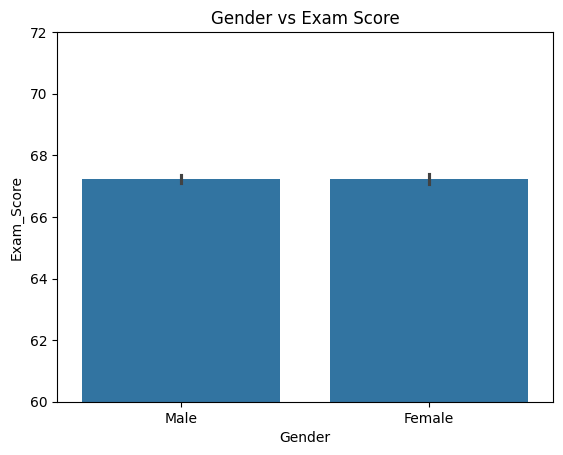

In [101]:
sns.barplot(x='Gender', y='Exam_Score', data=data )
plt.title('Gender vs Exam Score')
plt.ylim(60, 72)

(60.0, 72.0)

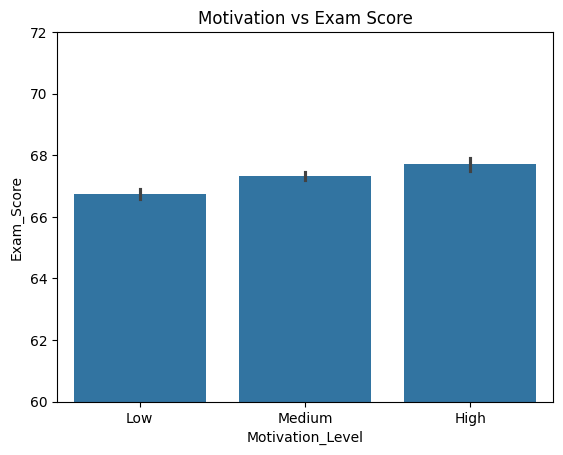

In [102]:
sns.barplot(x='Motivation_Level', y='Exam_Score', data=data )
plt.title('Motivation vs Exam Score')
plt.ylim(60, 72)

(60.0, 72.0)

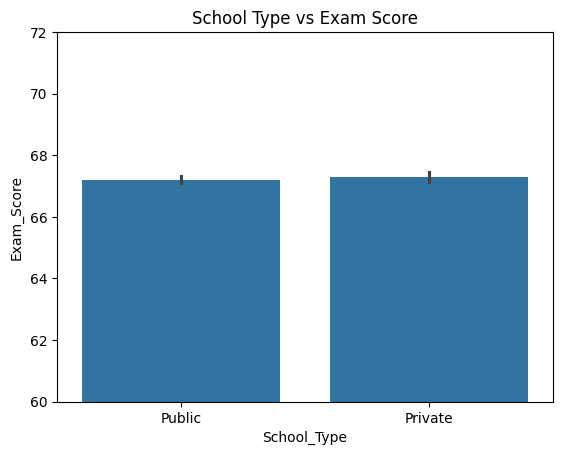

In [103]:
sns.barplot(x='School_Type', y='Exam_Score', data=data )
plt.title('School Type vs Exam Score')
plt.ylim(60, 72)

(60.0, 72.0)

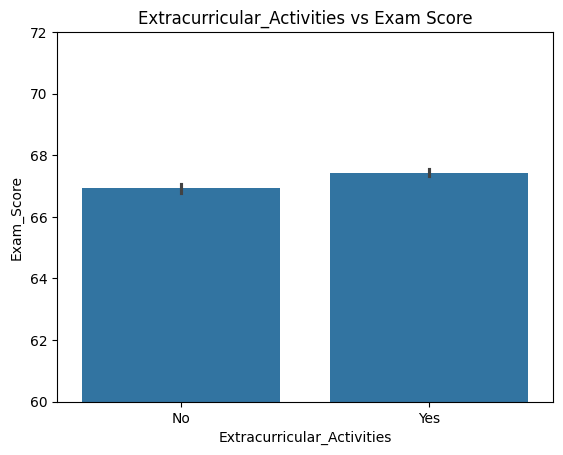

In [6]:
sns.barplot(x='Extracurricular_Activities', y='Exam_Score', data=data )
plt.title('Extracurricular_Activities vs Exam Score')
plt.ylim(60, 72)

(60.0, 72.0)

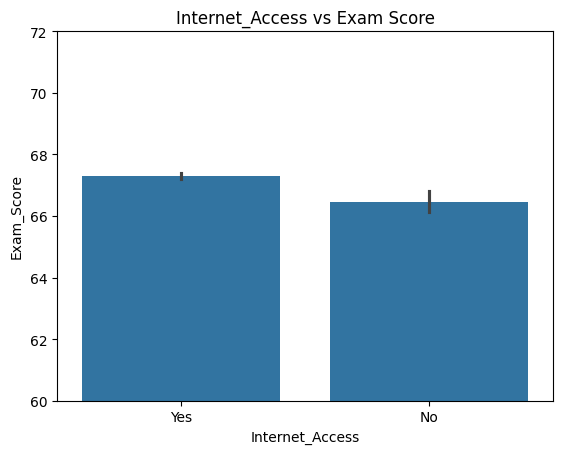

In [7]:
sns.barplot(x='Internet_Access', y='Exam_Score', data=data )
plt.title('Internet_Access vs Exam Score')
plt.ylim(60, 72)

 **TASK: REGRESSION (VARIABLE LIST A)**

In [8]:
#standardize data
x = data[['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions']]
y = data['Exam_Score']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)
# standardize the training and the test set
scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [9]:
#fit the model
model = linear_model.LinearRegression()
model.fit(x_train_scaled, y_train)
predicted = model.predict(x_test_scaled)

In [10]:
#print R^2
corr_coef = np.corrcoef(predicted, y_test)[1, 0]
R_squared = corr_coef ** 2
print(R_squared)
mse = mean_squared_error(y_test, predicted)
rmse = np.sqrt(mse)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

0.6399511028448553
MSE: 5.151047714929803
RMSE: 2.269591971022501


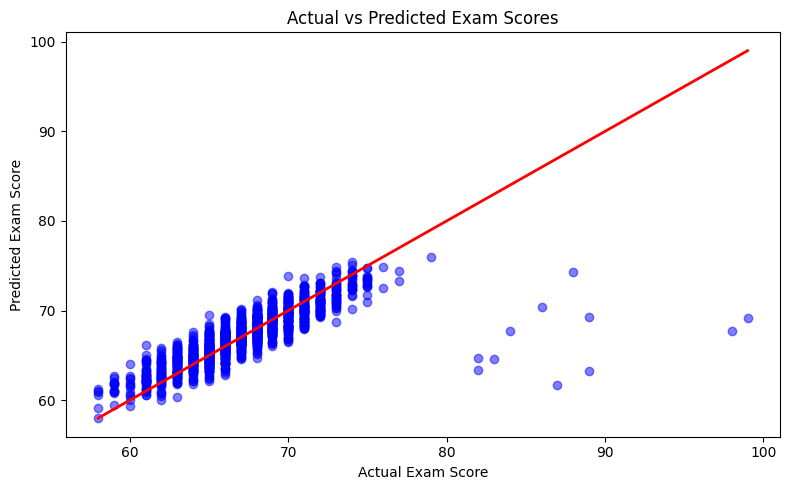

In [11]:
#GRAPH
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predicted, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)  # perfect fit line

plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted Exam Scores')
plt.tight_layout()
plt.show()

**TASK: REGRESSION (VARIABLE LIST B)**

In [12]:
#standardize data
x = data[['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions', 'Access_to_Resources', 'Teacher_Quality', 'Peer_Influence', 'Internet_Access','Learning_Disabilities']]
x = pd.get_dummies(x, columns=['Access_to_Resources', 'Teacher_Quality', 'Peer_Influence', 'Internet_Access', 'Learning_Disabilities'], drop_first=True).astype(int)
y = data['Exam_Score']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)
# standardize the training and the test set
scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [13]:
#fit the model
model = linear_model.LinearRegression()
model.fit(x_train_scaled, y_train)
predicted = model.predict(x_test_scaled)

In [14]:
#print R^2
corr_coef = np.corrcoef(predicted, y_test)[1, 0]
R_squared = corr_coef ** 2
print(R_squared)

mse = mean_squared_error(y_test, predicted)
rmse = np.sqrt(mse)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

0.6928572161746229
MSE: 4.391478527782902
RMSE: 2.095585485677667


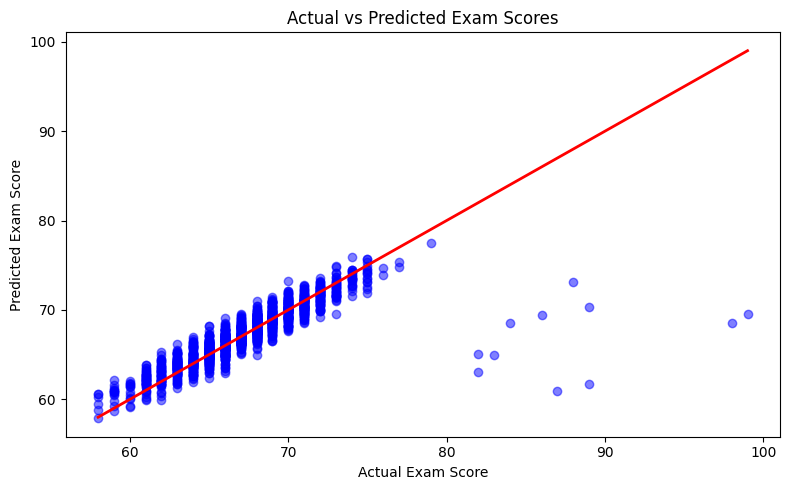

In [17]:
#GRAPH
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predicted, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)  # perfect fit line

plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted Exam Scores')
plt.tight_layout()
plt.show()

**TASK: CLASSIFICATION (VARIABLE SCHOOL TYPE)**

In [16]:
# target variable school type (public=1, private=0)
le = LabelEncoder()
data['School_Type_Encoded'] = le.fit_transform(data['School_Type'])
print("Class distribution:")
print(data['School_Type'].value_counts())

Class distribution:
School_Type
Public     4597
Private    2009
Name: count, dtype: int64


In [17]:
# select features and encode categoricals
features = [
    'Hours_Studied', 'Attendance','Tutoring_Sessions',
    'Access_to_Resources', 'Teacher_Quality',
    'Internet_Access', 'Parental_Involvement',
    'Family_Income','Distance_from_Home',
    'Parental_Education_Level'
]

X = data[features].copy()
y = data['School_Type_Encoded']

categorical_cols = X.select_dtypes(include='object').columns.tolist()
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True).astype(int)

In [18]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# standardize features
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [88]:
# find optimal k
k_values = range(1, 10)
train_accuracies = []
test_accuracies  = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_accuracies.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_accuracies.append(accuracy_score(y_test,  knn.predict(X_test_scaled)))

In [90]:
# fit knn with best k
best_k = k_values[np.argmax(test_accuracies)]
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

accuracy = metrics.accuracy_score(y_test, y_pred_knn)
error = 1 - accuracy
precision = metrics.precision_score(y_test, y_pred_knn, average = 'weighted')
recall = metrics.recall_score(y_test, y_pred_knn, average = 'weighted')
F1_score = metrics.f1_score(y_test, y_pred_knn, average = 'weighted')
print([accuracy, error, precision, recall, F1_score])

[0.6549636803874092, 0.34503631961259085, 0.5710523537418406, 0.6549636803874092, 0.5905136473300615]


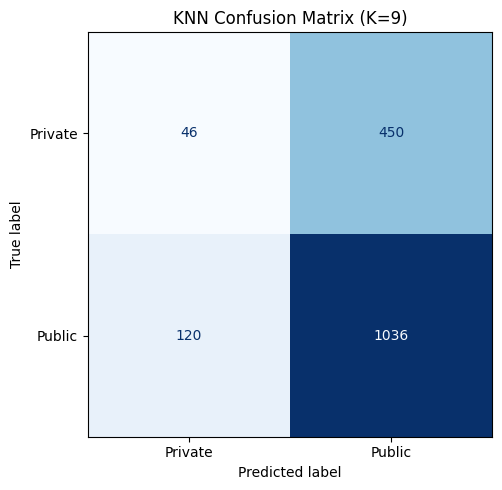

In [91]:
# knn confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'KNN Confusion Matrix (K={best_k})')
plt.tight_layout()
plt.show()

[Text(0.5, 0.8333333333333334, 'Parental_Education_Level_Postgraduate <= 0.762\nsamples = 4954\nvalue = [1513, 3441]\nclass = 1'),
 Text(0.25, 0.5, 'Hours_Studied <= -2.073\nsamples = 3978\nvalue = [1185, 2793]\nclass = 1'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'samples = 76\nvalue = [33, 43]\nclass = 1'),
 Text(0.375, 0.16666666666666666, 'samples = 3902\nvalue = [1152, 2750]\nclass = 1'),
 Text(0.75, 0.5, 'Parental_Involvement_Medium <= -0.015\nsamples = 976\nvalue = [328, 648]\nclass = 1'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'samples = 478\nvalue = [140, 338]\nclass = 1'),
 Text(0.875, 0.16666666666666666, 'samples = 498\nvalue = [188, 310]\nclass = 1')]

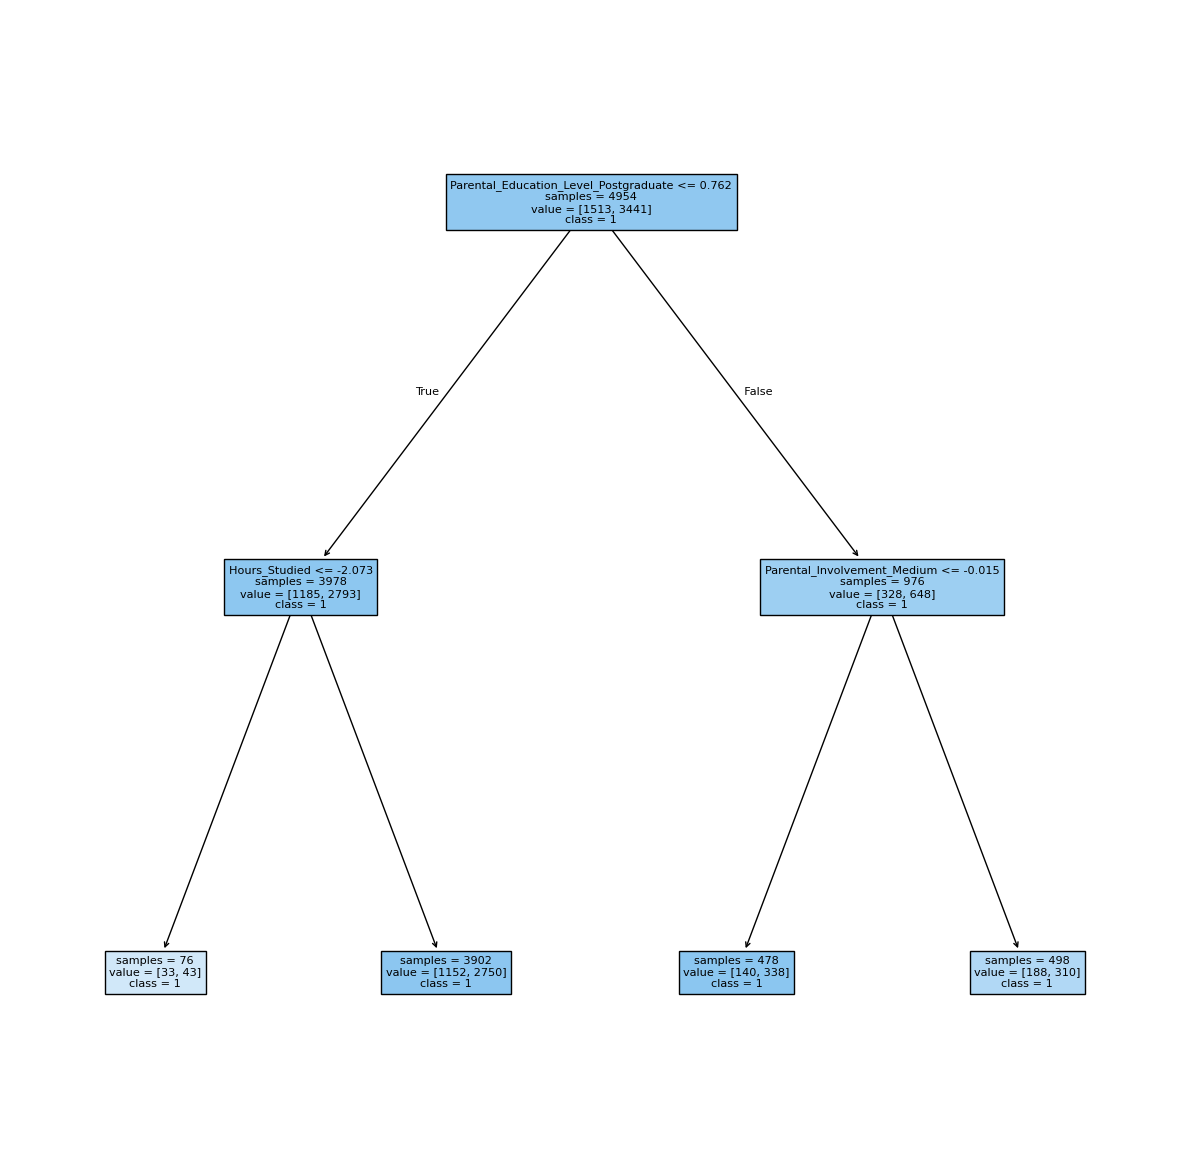

In [30]:
# find best depth
depths = range(1, 8)
train_acc_dt = []
test_acc_dt  = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=0, class_weight='balanced')
    dt.fit(X_train_scaled, y_train)
    train_acc_dt.append(accuracy_score(y_train, dt.predict(X_train_scaled)))
    test_acc_dt.append(accuracy_score(y_test,  dt.predict(X_test_scaled)))

best_depth = depths[np.argmax(test_acc_dt)]

dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=0)
dt_best.fit(X_train_scaled, y_train)
y_pred = dt_best.predict(X_test_scaled)

# plot the tree
plt.figure(figsize = (15,15))
tree.plot_tree(dt_best, feature_names = X_train.columns,
               class_names = dt_best.classes_.astype(str),
               filled = True, impurity = False)

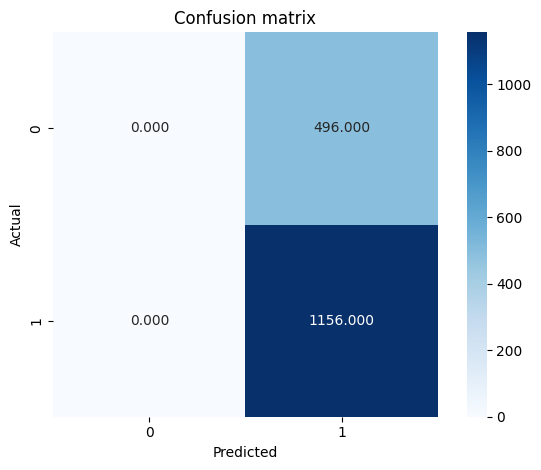

In [21]:


conf_matrix = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot = True, fmt = ".3f", square = True, cmap = plt.cm.Blues)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion matrix')
plt.tight_layout()

In [94]:
accuracy = metrics.accuracy_score(y_test, y_pred)
error = 1 - accuracy
precision = metrics.precision_score(y_test, y_pred, average = 'weighted')
recall = metrics.recall_score(y_test, y_pred, average = 'weighted')
F1_score = metrics.f1_score(y_test, y_pred, average = 'weighted')
print([accuracy, error, precision, recall, F1_score])

[0.6997578692493946, 0.30024213075060535, 0.4896610755764529, 0.6997578692493946, 0.576153915136966]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


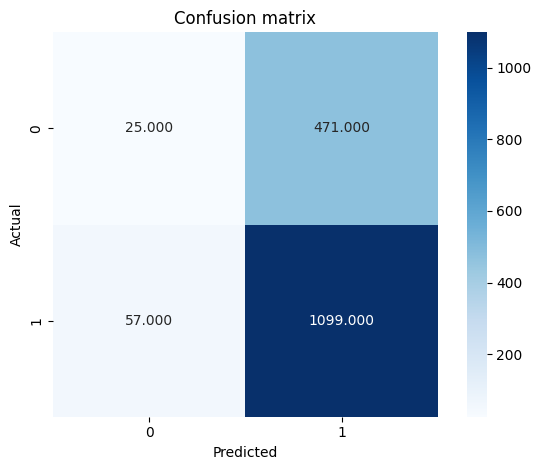

In [95]:
classifier = GaussianNB()
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)

conf_matrix = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot = True, fmt = ".3f", square = True, cmap = plt.cm.Blues)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion matrix')
plt.tight_layout()

In [96]:
accuracy = metrics.accuracy_score(y_test, y_pred)
error = 1 - accuracy
precision = metrics.precision_score(y_test, y_pred, average='weighted')
recall = metrics.recall_score(y_test, y_pred, average='weighted')
F1_score = metrics.f1_score(y_test, y_pred, average='weighted')
print([accuracy, error, precision, recall, F1_score])

[0.6803874092009685, 0.3196125907990315, 0.5813677434595169, 0.6803874092009685, 0.590193998115028]
